# Simulation DD

## local

In [43]:
%load_ext autoreload
%autoreload 2

import os
ROOT_DIR = os.getcwd()[:os.getcwd().rfind('HEOM')]+ 'HEOM'
os.chdir(ROOT_DIR)

from ttheom import *
plt.style.use('ttheom-default')

import numpy as np 
import qutip as q
import matplotlib.pyplot as plt
import pandas as pd
import time

red, blue, orange, grey = '#B74244', '#459DD9', '#ED8532', '#A9ACBC'

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
import numpy as np
import scipy.constants as c
from qiskit import QuantumCircuit
from ttheom import calcTimeEvo

# Qiskit quantum circuit
qc = QuantumCircuit(1)

# Manual idle segment corresponding to 10 ns.
# The XY4 sequence is X - Y - X - Y with idle intervals between pulses.
dtfb = 0.002 / (10 * np.pi * 1e-3)  # ps
idling_manual = int(10 / (1e-3 * dtfb))  # 10 ns

for _ in range(2):
    qc.delay(idling_manual, 0)
    qc.rx(np.pi, 0)
    qc.delay(idling_manual, 0)
    qc.ry(np.pi, 0)

# for _ in range(2):
#     qc.delay(idlingManual)
#     qc.ry(np.pi, 0)
#     qc.delay(idlingManual)
#     qc.rx(np.pi, 0)

kwargs = {
    "numQ": 1,
    "freqQ": [5],  # GHz
    "rhoIni": np.array(
        [
            [0.5, 0.5],
            [0.5, 0.5],
        ],
        dtype=np.complex128,
    ),
    "gateTime": [16],  # ns
    "idlingTime": 0,  # ns
    "T": c.hbar * 10 * np.pi * 1e9 / (8e-3 * c.k),  # mK
    "T1": 1e-6 / (2 * np.pi) * (2 * np.pi * 1e9) / (10 * np.pi),  # us
    "omegaC": 50,
    "exp": 1,
    "tol": 1e-6,
    "dtFB": dtfb,  # ps
    "depth": [1],
    "bondDim": 5,
    "strideTime": 0.1,  # ns
    "useRFPlus": False,
    "isRK13": False,
}

kwargs["directory"] = "development/results/local/sim_DD"
kwargs["fileName"] = "xy4_Ohmic_s1"
kwargs["qc"] = qc

# expected time: 31h (107s/it) 
calcTimeEvo(**kwargs)

development/results/local/sim_DD
Saved quantum circuit data to C:\Users\Dennis Herb\OneDrive\2_Uni\Doktor\python_projects\HEOM\development\development/results/local/sim_DD\qcData_xy4_Ohmic_s1.
{'idlingTime': np.float64(0.0), 'gateList': [[[0], 'rxyStep', {'omega': -1.0, 'gateTime': 502.6548245743669}]], 'bath': [{'type': 'broadband', 'beta': 8.000000000000002, 'kappa': 1.5915494309189538e-07, 'omegaC': 50, 'exp': 1, 'tol': 1e-06}], 'dtFB': np.float64(0.002), 'stride': 1570, 'depth': [1], 'bondDim': 5, 'isRK13': False, 'useRFPlus': False, 'rho': {'numQ': 1, 'omegaQ': [1.0], 'rhoReal': [[0.5, 0.5], [0.5, 0.5]], 'rhoImag': [[0.0, 0.0], [0.0, 0.0]]}, 'VTmp': {'real': [[[0.0, 1.0], [1.0, 0.0]]], 'imag': [[[0.0, 0.0], [0.0, 0.0]]]}, 'omegaQmax': np.float64(31.41592653589793)}


C:\Users\Dennis Herb\OneDrive\2_Uni\Doktor\python_projects\HEOM\ttheom\bath\broadband.py:56: RuntimeWarning: overflow encountered in exp
  / (1. + (x / omegaC)**2)**2 / (1. - np.exp(-beta * x)))


Saved result data to C:\Users\Dennis Herb\OneDrive\2_Uni\Doktor\python_projects\HEOM\development\development/results/local/sim_DD\xy4_Ohmic_s1.csv.
Total step: 1633624


  0%|▏                                                                                                                                              | 1/1040 [02:29<43:09:26, 149.53s/it]


KeyboardInterrupt: 

In [3]:
import numpy as np
import scipy.constants as c
from qiskit import QuantumCircuit
from ttheom import calcTimeEvo

# Qiskit quantum circuit
qc = QuantumCircuit(1)

# Manual idle segment corresponding to 10 ns.
# The XY4 sequence is X - Y - X - Y with idle intervals between pulses.
dtfb = 0.002 / (10 * np.pi * 1e-3)  # ps
idling_manual = int(10 / (1e-3 * dtfb))  # 10 ns

for _ in range(2):
    qc.delay(idling_manual, 0)
    qc.rx(np.pi, 0)
    qc.delay(idling_manual, 0)
    qc.ry(np.pi, 0)

# for _ in range(2):
#     qc.delay(idlingManual)
#     qc.ry(np.pi, 0)
#     qc.delay(idlingManual)
#     qc.rx(np.pi, 0)

kwargs = {
    "numQ": 1,
    "freqQ": [5],  # GHz
    "rhoIni": np.array(
        [
            [0.5, 0.5],
            [0.5, 0.5],
        ],
        dtype=np.complex128,
    ),
    "gateTime": [16],  # ns
    "idlingTime": 0,  # ns
    "T": c.hbar * 10 * np.pi * 1e9 / (8e-3 * c.k),  # mK
    "T1": 1e-6 / (2 * np.pi) * (2 * np.pi * 1e9) / (10 * np.pi),  # us
    "omegaC": 50,
    "exp": 1 / 8,
    "tol": 1e-6,
    "dtFB": dtfb,  # ps
    "depth": [1],
    "bondDim": 5,
    "strideTime": 0.1,  # ns
    "useRFPlus": False,
    "isRK13": False,
}

kwargs["directory"] = "development/results/local/sim_DD"
kwargs["fileName"] = "xy4_Ohmic_s8"
kwargs["qc"] = qc

# expected time: 59h (204s/it)
calcTimeEvo(**kwargs)

development/results/local/sim_DD
Saved quantum circuit data to C:\Users\Dennis Herb\OneDrive\2_Uni\Doktor\python_projects\HEOM\development\development/results/local/sim_DD\qcData_xy4_Ohmic_s8.
{'idlingTime': np.float64(0.0), 'gateList': [[[0], 'rxyStep', {'omega': -1.0, 'gateTime': 502.6548245743669}]], 'bath': [{'type': 'broadband', 'beta': 8.000000000000002, 'kappa': 1.5915494309189538e-07, 'omegaC': 50, 'exp': 0.125, 'tol': 1e-06}], 'dtFB': np.float64(0.002), 'stride': 1570, 'depth': [1], 'bondDim': 5, 'isRK13': False, 'useRFPlus': False, 'rho': {'numQ': 1, 'omegaQ': [1.0], 'rhoReal': [[0.5, 0.5], [0.5, 0.5]], 'rhoImag': [[0.0, 0.0], [0.0, 0.0]]}, 'VTmp': {'real': [[[0.0, 1.0], [1.0, 0.0]]], 'imag': [[[0.0, 0.0], [0.0, 0.0]]]}, 'omegaQmax': np.float64(31.41592653589793)}


C:\Users\Dennis Herb\OneDrive\2_Uni\Doktor\python_projects\HEOM\.venv\Lib\site-packages\baryrat.py:280: RuntimeWarning: divide by zero encountered in divide
  C_pol = 1.0 / (pol[:,None] - zj[None,:])
C:\Users\Dennis Herb\OneDrive\2_Uni\Doktor\python_projects\HEOM\.venv\Lib\site-packages\baryrat.py:280: RuntimeWarning: invalid value encountered in divide
  C_pol = 1.0 / (pol[:,None] - zj[None,:])
C:\Users\Dennis Herb\OneDrive\2_Uni\Doktor\python_projects\HEOM\.venv\Lib\site-packages\baryrat.py:281: RuntimeWarning: invalid value encountered in dot
  N_pol = C_pol.dot(fj*wj)
C:\Users\Dennis Herb\OneDrive\2_Uni\Doktor\python_projects\HEOM\.venv\Lib\site-packages\baryrat.py:283: RuntimeWarning: invalid value encountered in divide
  res = N_pol / Ddiff_pol


Saved result data to C:\Users\Dennis Herb\OneDrive\2_Uni\Doktor\python_projects\HEOM\development\development/results/local/sim_DD\xy4_Ohmic_s8.csv.
Total step: 1633624


  0%|▏                                                                                                                                             | 1/1040 [06:50<118:34:18, 410.84s/it]


KeyboardInterrupt: 

In [6]:
import numpy as np
import scipy.constants as c
from qiskit import QuantumCircuit
from ttheom import calcTimeEvo

# Qiskit quantum circuit
qc = QuantumCircuit(1)

# Manual idle segment corresponding to 10 ns.
# The XY4 sequence is X - Y - X - Y with idle intervals between pulses.
dtfb = 0.002 / (10 * np.pi * 1e-3)  # ps
idling_manual = int(10 / (1e-3 * dtfb))  # 10 ns

for _ in range(2):
    qc.delay(idling_manual, 0)
    qc.rx(np.pi, 0)
    qc.delay(idling_manual, 0)
    qc.ry(np.pi, 0)

for _ in range(2):
    qc.delay(idling_manual, 0)
    qc.ry(np.pi, 0)
    qc.delay(idling_manual, 0)
    qc.rx(np.pi, 0)

kwargs = {
    "numQ": 1,
    "freqQ": [5],  # GHz
    "rhoIni": np.array(
        [
            [0.5, 0.5],
            [0.5, 0.5],
        ],
        dtype=np.complex128,
    ),
    "gateTime": [16],  # ns
    "idlingTime": 0,  # ns
    "T": c.hbar * 10 * np.pi * 1e9 / (8e-3 * c.k),  # mK
    "T1": 1e-6 / (2 * np.pi) * (2 * np.pi * 1e9) / (10 * np.pi),  # us
    "omegaC": 50,
    "exp": 1,
    "tol": 1e-6,
    "dtFB": dtfb,  # ps
    "depth": [1],
    "bondDim": 5,
    "strideTime": 0.1,  # ns
    "useRFPlus": False,
    "isRK13": False,
}

kwargs["directory"] = "development/results/local/sim_DD"
kwargs["fileName"] = "xy8_Ohmic_s1"
kwargs["qc"] = qc

# expected time: 59h (102s/it)
calcTimeEvo(**kwargs)

development/results/local/sim_DD
Saved quantum circuit data to C:\Users\Dennis Herb\OneDrive\2_Uni\Doktor\python_projects\HEOM\development\development/results/local/sim_DD\qcData_xy8_Ohmic_s1.
{'idlingTime': np.float64(0.0), 'gateList': [[[0], 'rxyStep', {'omega': -1.0, 'gateTime': 502.6548245743669}]], 'bath': [{'type': 'broadband', 'beta': 8.000000000000002, 'kappa': 1.5915494309189538e-07, 'omegaC': 50, 'exp': 1, 'tol': 1e-06}], 'dtFB': np.float64(0.002), 'stride': 1570, 'depth': [1], 'bondDim': 5, 'isRK13': False, 'useRFPlus': False, 'rho': {'numQ': 1, 'omegaQ': [1.0], 'rhoReal': [[0.5, 0.5], [0.5, 0.5]], 'rhoImag': [[0.0, 0.0], [0.0, 0.0]]}, 'VTmp': {'real': [[[0.0, 1.0], [1.0, 0.0]]], 'imag': [[[0.0, 0.0], [0.0, 0.0]]]}, 'omegaQmax': np.float64(31.41592653589793)}
Saved result data to C:\Users\Dennis Herb\OneDrive\2_Uni\Doktor\python_projects\HEOM\development\development/results/local/sim_DD\xy8_Ohmic_s1.csv.
Total step: 3267248


  1%|█▏                                                                                                                                            | 17/2081 [29:32<59:46:39, 104.26s/it]


KeyboardInterrupt: 

In [7]:
import numpy as np
import scipy.constants as c
from qiskit import QuantumCircuit
from ttheom import calcTimeEvo

# Qiskit quantum circuit
qc = QuantumCircuit(1)

# Manual idle segment corresponding to 10 ns.
# The XY4 sequence is X - Y - X - Y with idle intervals between pulses.
dtfb = 0.002 / (10 * np.pi * 1e-3)  # ps
idling_manual = int(10 / (1e-3 * dtfb))  # 10 ns

for _ in range(2):
    qc.delay(idling_manual, 0)
    qc.rx(np.pi, 0)
    qc.delay(idling_manual, 0)
    qc.ry(np.pi, 0)

for _ in range(2):
    qc.delay(idling_manual, 0)
    qc.ry(np.pi, 0)
    qc.delay(idling_manual, 0)
    qc.rx(np.pi, 0)

kwargs = {
    "numQ": 1,
    "freqQ": [5],  # GHz
    "rhoIni": np.array(
        [
            [0.5, 0.5],
            [0.5, 0.5],
        ],
        dtype=np.complex128,
    ),
    "gateTime": [16],  # ns
    "idlingTime": 0,  # ns
    "T": c.hbar * 10 * np.pi * 1e9 / (8e-3 * c.k),  # mK
    "T1": 1e-6 / (2 * np.pi) * (2 * np.pi * 1e9) / (10 * np.pi),  # us
    "omegaC": 50,
    "exp": 1 / 8,
    "tol": 1e-6,
    "dtFB": dtfb,  # ps
    "depth": [1],
    "bondDim": 5,
    "strideTime": 0.1,  # ns
    "useRFPlus": False,
    "isRK13": False,
}

kwargs["directory"] = "development/results/local/sim_DD"
kwargs["fileName"] = "xy8_Ohmic_s8"
kwargs["qc"] = qc

# expected time: 127h (220s/it)
calcTimeEvo(**kwargs)

development/results/local/sim_DD
Saved quantum circuit data to C:\Users\Dennis Herb\OneDrive\2_Uni\Doktor\python_projects\HEOM\development\development/results/local/sim_DD\qcData_xy8_Ohmic_s8.
{'idlingTime': np.float64(0.0), 'gateList': [[[0], 'rxyStep', {'omega': -1.0, 'gateTime': 502.6548245743669}]], 'bath': [{'type': 'broadband', 'beta': 8.000000000000002, 'kappa': 1.5915494309189538e-07, 'omegaC': 50, 'exp': 0.125, 'tol': 1e-06}], 'dtFB': np.float64(0.002), 'stride': 1570, 'depth': [1], 'bondDim': 5, 'isRK13': False, 'useRFPlus': False, 'rho': {'numQ': 1, 'omegaQ': [1.0], 'rhoReal': [[0.5, 0.5], [0.5, 0.5]], 'rhoImag': [[0.0, 0.0], [0.0, 0.0]]}, 'VTmp': {'real': [[[0.0, 1.0], [1.0, 0.0]]], 'imag': [[[0.0, 0.0], [0.0, 0.0]]]}, 'omegaQmax': np.float64(31.41592653589793)}
Saved result data to C:\Users\Dennis Herb\OneDrive\2_Uni\Doktor\python_projects\HEOM\development\development/results/local/sim_DD\xy8_Ohmic_s8.csv.
Total step: 3267248


  0%|▏                                                                                                                                             | 3/2081 [14:19<165:17:34, 286.36s/it]


KeyboardInterrupt: 

## HPC

In [24]:
import numpy as np
import scipy.constants as c
from qiskit import QuantumCircuit
from ttheom import calcTimeEvo

# Qiskit quantum circuit
qc = QuantumCircuit(1)

# Manual idle segment corresponding to 10 ns.
# The XY4 sequence is X - Y - X - Y with idle intervals between pulses.
dtfb = 0.002 / (10 * np.pi * 1e-3)  # ps
idling_manual = int(10 / (1e-3 * dt_fb))  # 10 ns

for _ in range(2):
    qc.delay(idling_manual, 0)
    qc.rx(np.pi, 0)
    qc.delay(idling_manual, 0)
    qc.ry(np.pi, 0)

# for _ in range(2):
#     qc.delay(idlingManual)
#     qc.ry(np.pi, 0)
#     qc.delay(idlingManual)
#     qc.rx(np.pi, 0)

kwargs = {
    "numQ": 1,
    "freqQ": [5],  # GHz
    "rhoIni": np.array(
        [
            [0.5, 0.5],
            [0.5, 0.5],
        ],
        dtype=np.complex128,
    ),
    "gateTime": [16],  # ns
    "idlingTime": 0,  # ns
    "T": c.hbar * 10 * np.pi * 1e9 / (8e-3 * c.k),  # mK
    "T1": 1e-6 / (2 * np.pi) * (2 * np.pi * 1e9) / (10 * np.pi),  # us
    "omegaC": 50,
    "exp": 1,
    "tol": 1e-6,
    "dtFB": dtfb,  # ps
    "depth": [1],
    "bondDim": 5,
    "strideTime": 0.1,  # ns
    "useRFPlus": False,
    "isRK13": False,
}

kwargs["directory"] = "development/results/hpc/sim_DD"
kwargs["fileName"] = "DD_xy4_s1"
kwargs["qc"] = qc

In [22]:
submissionParams = {}
submissionParams['hostname'] = 'justus2.uni-ulm.de'
submissionParams['schedulerName'] = 'slurm'
submissionParams['numNodes'] = 1
submissionParams['cpusPerTask'] = 1
submissionParams['maxTime'] = '336:00:00'
submissionParams['others'] = ''
submissionParams['venvPath'] = '$HOME/python_HEOM/.venv'

submissionParams['username'] = "ul_kfo52" # input('User Name: ')
submissionParams['emailAddress'] = "dennis.herb@uni-ulm.de" # input('Email Address: ')
submissionParams['password'] = "3bA5huBB5n!NdU8" # getpass.getpass('Password: ')

calcTimeEvoHPC(submissionParams, **kwargs)

Your OTP:  ········


Submitted batch job 21415108

Save the job ID! It is used for getting results.


In [23]:
import getpass
kwargs["directory"] = "development/results/hpc/sim_DD"
kwargs["fileName"] = "DD_xy4_s1"
jobID = ""

downloadParams = {}
downloadParams['hostname'] = 'justus2.uni-ulm.de'
downloadParams['username'] = "ul_kfo52" 
downloadParams['password'] = "3bA5huBB5n!NdU8"
downloadParams['otp'] = getpass.getpass('Your OTP: ')
downloadParams['schedulerName'] = 'slurm'

csvFilePath = os.path.join(os.getcwd(), directory, fileName + '.csv')
downloadResult(downloadParams, jobID, csvFilePath)

Your OTP:  ········


## reload

{'directory': 'development/results/paper/sim_DD', 'fileName': 'xy4_Ohmic_s8', 'numQ': 1, 'freqQ': [5.0], 'gateTime': [16.0], 'T': array([29.99526921]), 'T1': array([31.83098862]), 'omegaC': [50], 'exp': [0.125], 'tol': [1e-06], 'idlingTime': 0.0, 'dtFB': 0.06366197723675814, 'depth': [1], 'bondDim': 5, 'strideTime': 0.09994930426171028, 'useRFPlus': False, 'isRK13': False, 'rhoIni': array([[0.5+0.j, 0.5+0.j],
       [0.5+0.j, 0.5+0.j]]), 'qc': <qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x00000227101AC290>}
------------
{'idlingTime': 0.0, 'gateList': [[[0], 'rxyStep', {'omega': -1.0, 'gateTime': 502.6548245743669}]], 'bath': [{'type': 'broadband', 'beta': 8.000000000000002, 'kappa': 1.5915494309189538e-07, 'omegaC': 50, 'exp': 0.125, 'tol': 1e-06}], 'dtFB': 0.002, 'stride': 1570, 'depth': [1], 'bondDim': 5, 'isRK13': False, 'useRFPlus': False, 'rho': {'numQ': 1, 'omegaQ': [1.0], 'rhoReal': [[0.5, 0.5], [0.5, 0.5]], 'rhoImag': [[0.0, 0.0], [0.0, 0.0]]}, 'VTmp': {'real': [[[

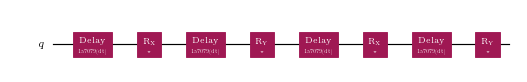

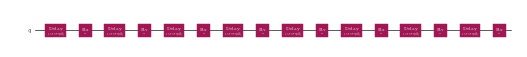

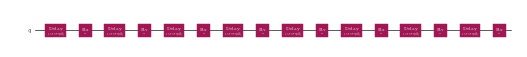

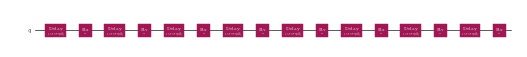

In [16]:
directory = "development/results/paper/sim_DD"
fileNames = ['DD_xy4_s8', 'DD_xy4_s1', 'DD_xy8_s8', 'DD_xy8_s1']

for i, fileName in enumerate(fileNames):
    
    # load kwargs from QPY file 
    kwargs = getKwargs(directory, fileName)
    print(kwargs)
    print('------------')
    print(kwargs['qc'].metadata)
    print('------------')
    
    fig, ax = plt.subplots()
    kwargs['qc'].draw('mpl', ax=ax)
    
    # load result from CSV file
    # t_list, rdo_list = getResult(directory, fileName)

{'directory': 'development/results/hpc/sim_DD_1', 'fileName': '21228108', 'numQ': 1, 'freqQ': [5.0], 'gateTime': [16.0], 'T': array([30.]), 'T1': array([32.]), 'omegaC': [20], 'exp': [1], 'tol': [1e-06], 'idlingTime': 0.0, 'dtFB': 0.06366197723675814, 'depth': [1], 'bondDim': 5, 'strideTime': 0.09994930426171028, 'useRFPlus': False, 'isRK13': False, 'rhoIni': array([[1.+0.j, 0.+0.j],
       [0.+0.j, 0.+0.j]]), 'qc': <qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x0000022710437350>}
------------
{'idlingTime': 0.0, 'gateList': [[[0], 'rxyStep', {'omega': -1.0, 'gateTime': 502.6548245743669}]], 'bath': [{'type': 'broadband', 'beta': 7.998738455610369, 'kappa': 1.5831434944115278e-07, 'omegaC': 20, 'exp': 1, 'tol': 1e-06}], 'dtFB': 0.002, 'stride': 1570, 'depth': [1], 'bondDim': 5, 'isRK13': False, 'useRFPlus': False, 'rho': {'numQ': 1, 'omegaQ': [1.0], 'rhoReal': [[1.0, 0.0], [0.0, 0.0]], 'rhoImag': [[0.0, 0.0], [0.0, 0.0]]}, 'VTmp': {'real': [[[0.0, 1.0], [1.0, 0.0]]], 'imag':

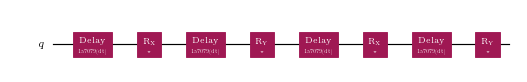

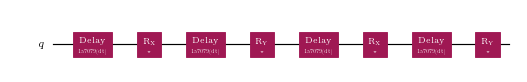

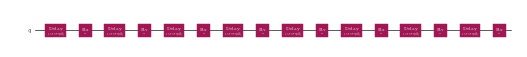

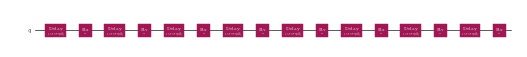

In [26]:
directory = "development/results/hpc/sim_DD_1"
fileNames = ['21228108', '21227941', '21227919', '21227937']

for i, fileName in enumerate(fileNames):
    
    # load kwargs from QPY file 
    kwargs = getKwargs(directory, fileName)
    print(kwargs)
    print('------------')
    print(kwargs['qc'].metadata)
    print('------------')
    
    fig, ax = plt.subplots()
    kwargs['qc'].draw('mpl', ax=ax)
    
    # load result from CSV file
    # t_list, rdo_list = getResult(directory, fileName)

{'directory': 'development/results/hpc/sim_DD_2', 'fileName': '21415108', 'numQ': 1, 'freqQ': [5.0], 'gateTime': [16.0], 'T': array([29.99526921]), 'T1': array([31.83098862]), 'omegaC': [50], 'exp': [1], 'tol': [1e-06], 'idlingTime': 0.0, 'dtFB': 0.06366197723675814, 'depth': [1], 'bondDim': 5, 'strideTime': 0.09994930426171028, 'useRFPlus': False, 'isRK13': False, 'rhoIni': array([[0.5+0.j, 0.5+0.j],
       [0.5+0.j, 0.5+0.j]]), 'qc': <qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x00000227108FF7D0>}
------------
{'idlingTime': 0.0, 'gateList': [[[0], 'rxyStep', {'omega': -1.0, 'gateTime': 502.6548245743669}]], 'bath': [{'type': 'broadband', 'beta': 8.000000000000002, 'kappa': 1.5915494309189538e-07, 'omegaC': 50, 'exp': 1, 'tol': 1e-06}], 'dtFB': 0.002, 'stride': 1570, 'depth': [1], 'bondDim': 5, 'isRK13': False, 'useRFPlus': False, 'rho': {'numQ': 1, 'omegaQ': [1.0], 'rhoReal': [[0.5, 0.5], [0.5, 0.5]], 'rhoImag': [[0.0, 0.0], [0.0, 0.0]]}, 'VTmp': {'real': [[[0.0, 1.0], [

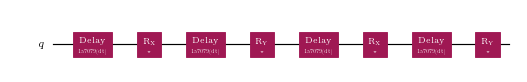

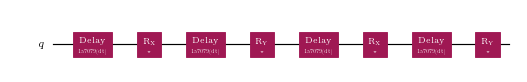

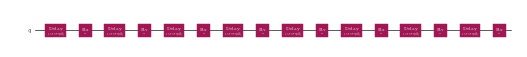

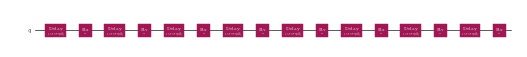

In [25]:
directory = "development/results/hpc/sim_DD_2"
fileNames = ['21415108', '21415111', '21415112', '21415177']

for i, fileName in enumerate(fileNames):
    
    # load kwargs from QPY file 
    kwargs = getKwargs(directory, fileName)
    print(kwargs)
    print('------------')
    print(kwargs['qc'].metadata)
    print('------------')
    
    fig, ax = plt.subplots()
    kwargs['qc'].draw('mpl', ax=ax)
    
    # load result from CSV file
    # t_list, rdo_list = getResult(directory, fileName)

## eval

### XY4

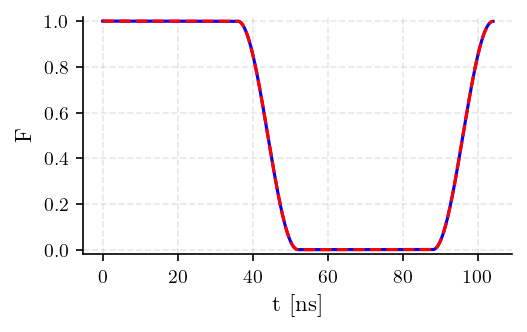

In [40]:
directory = "development/results/paper/sim_DD"
fileNames = ['DD_xy4_s8', 'DD_xy4_s1']

fig, ax = plt.subplots()

colors = ['b', 'r', 'g']
labels = [r'$s=1/8$', r'$s=1/2$', r'$s=1$']
ls = ['-','--', ':']

for i, fileName in enumerate(fileNames):
    
    kwargs = getKwargs(directory, fileName)
    t_list, rdo_list = getResult(directory, fileName)

    omegaQ = 2*np.pi*np.array(kwargs['freqQ'])
    omegaQmax = max(omegaQ)
    t = t_list / omegaQmax

    U = Operator(kwargs["qc"]).data
    target = U @ kwargs["rhoIni"] @ U.conj().T
    fids = [getFidelity(rho, target) for rho in rdo_list]

    ax.plot(t, fids, linewidth=1.5, color=colors[i], label=labels[i], ls=ls[i])
    ax.set_xlabel("t [ns]")
    ax.set_ylabel("F")
    ax.set_ylim(-0.02, 1.02)
    ax.grid(True, alpha=0.3)

development/results/paper/sim_DD
Saved quantum circuit data to C:\Users\Dennis Herb\OneDrive\2_Uni\Doktor\python_projects\HEOM\development/results/paper/sim_DD\qcData_DD_xy4_s8.
{'idlingTime': np.float64(0.0), 'gateList': [[[0], 'rxyStep', {'omega': -1.0, 'gateTime': 502.6548245743669}]], 'bath': [{'type': 'broadband', 'beta': 8.000000000000002, 'kappa': 1.5915494309189538e-07, 'omegaC': 50, 'exp': 0.125, 'tol': 1e-06}], 'dtFB': np.float64(0.002), 'stride': 1570, 'depth': [1], 'bondDim': 5, 'isRK13': False, 'useRFPlus': False, 'rho': {'numQ': 1, 'omegaQ': [1.0], 'rhoReal': [[0.5, 0.5], [0.5, 0.5]], 'rhoImag': [[0.0, 0.0], [0.0, 0.0]]}, 'VTmp': {'real': [[[0.0, 1.0], [1.0, 0.0]]], 'imag': [[[0.0, 0.0], [0.0, 0.0]]]}, 'omegaQmax': np.float64(31.41592653589793)}


C:\Users\Dennis Herb\OneDrive\2_Uni\Doktor\python_projects\HEOM\ttheom\bath\broadband.py:56: RuntimeWarning: overflow encountered in exp
  / (1. + (x / omegaC)**2)**2 / (1. - np.exp(-beta * x)))
C:\Users\Dennis Herb\OneDrive\2_Uni\Doktor\python_projects\HEOM\.venv\Lib\site-packages\baryrat.py:280: RuntimeWarning: divide by zero encountered in divide
  C_pol = 1.0 / (pol[:,None] - zj[None,:])
C:\Users\Dennis Herb\OneDrive\2_Uni\Doktor\python_projects\HEOM\.venv\Lib\site-packages\baryrat.py:280: RuntimeWarning: invalid value encountered in divide
  C_pol = 1.0 / (pol[:,None] - zj[None,:])
C:\Users\Dennis Herb\OneDrive\2_Uni\Doktor\python_projects\HEOM\.venv\Lib\site-packages\baryrat.py:281: RuntimeWarning: invalid value encountered in dot
  N_pol = C_pol.dot(fj*wj)
C:\Users\Dennis Herb\OneDrive\2_Uni\Doktor\python_projects\HEOM\.venv\Lib\site-packages\baryrat.py:283: RuntimeWarning: invalid value encountered in divide
  res = N_pol / Ddiff_pol
C:\Users\Dennis Herb\OneDrive\2_Uni\Doktor\p

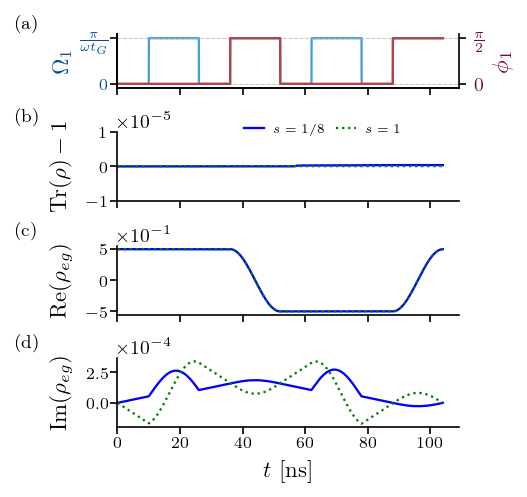

In [48]:
directory = "development/results/paper/sim_DD"
fileNames = ['DD_xy4_s8', 'DD_xy4_s1']

colors = ["b", "r", "g"]
labels = [r"$s=1/8$", r"$s=1/2$", r"$s=1$"]
ls = ["-", "--", ":"]

fig, axes = plt.subplots(
    4,
    1,
    figsize=(3.4, 3.2),
    sharex=True,
    gridspec_kw={"height_ratios": [0.8, 1.0, 1.0, 1.0]},
)

# (a) pulse sequence
kwargs = getKwargs(directory, fileNames[0])
fig, ax = plotPulseSeq(fig=fig, ax=axes[0], **kwargs)
axes[0].set_xlabel("")

for i, fileName in [[0, fileNames[0]], [2, fileNames[1]]]:
    kwargs = getKwargs(directory, fileName)
    t_list, rdo_list = getResult(directory, fileName)

    omegaQ = 2 * np.pi * np.array(kwargs["freqQ"])
    omegaQmax = max(omegaQ)
    t = t_list / omegaQmax

    trace_list = [np.trace(rho) - 1 for rho in rdo_list]
    rho_eg_real = [dm[0, 1].real for dm in rdo_list]
    rho_eg_imag = [dm[0, 1].imag for dm in rdo_list]

    axes[1].plot(t, trace_list, color=colors[i], label=labels[i], ls=ls[i], lw=1.1)
    axes[2].plot(t, rho_eg_real, color=colors[i], label=labels[i], ls=ls[i], lw=1.1)
    axes[3].plot(t, rho_eg_imag, color=colors[i], label=labels[i], ls=ls[i], lw=1.1)

axes[1].set_ylim(-1e-5, 1e-5)
axes[1].set_ylabel(r"$\mathrm{Tr}(\rho)-1$")
axes[2].set_ylabel(r"$\mathrm{Re}(\rho_{eg})$")
axes[3].set_ylabel(r"$\mathrm{Im}(\rho_{eg})$")
axes[2].ticklabel_format(axis="y", style="sci", scilimits=(0, 0))
axes[3].ticklabel_format(axis="y", style="sci", scilimits=(0, 0))
axes[-1].set_xlabel(r"$t$ [ns]")

for ax in axes:
    ax.set_xlim(0)
    ax.tick_params(axis="both", labelsize=8, pad=1)

# panel labels
panel_labels = ["(a)", "(b)", "(c)", "(d)"]
for ax, label in zip(axes, panel_labels):
    ax.text(
        -0.3,
        1.35,
        label,
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=9,
        fontweight="bold",
    )

# one shared legend
axes[1].legend(
    fontsize=6,
    ncols=3,
    frameon=False,
    loc="upper center",
    bbox_to_anchor=(0.6, 1.3),
    handlelength=1.6,
    columnspacing=0.9,
)

fig.align_ylabels(axes)
fig.subplots_adjust(hspace=0.25)

fig.savefig(os.path.join(directory, "DD_xy4_comparison.pdf"), bbox_inches="tight")
fig.savefig(os.path.join(directory, "DD_xy4_comparison.svg"), bbox_inches="tight")

### XY8

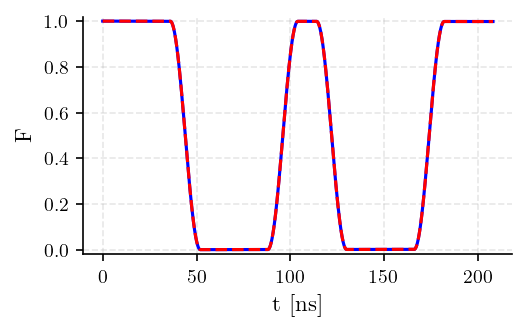

In [49]:
directory = "development/results/paper/sim_DD"
fileNames = ['DD_xy8_s8', 'DD_xy8_s1']

fig, ax = plt.subplots()

colors = ['b', 'r', 'g']
labels = [r'$s=1/8$', r'$s=1/2$', r'$s=1$']
ls = ['-','--', ':']

for i, fileName in enumerate(fileNames):
    
    kwargs = getKwargs(directory, fileName)
    t_list, rdo_list = getResult(directory, fileName)

    omegaQ = 2*np.pi*np.array(kwargs['freqQ'])
    omegaQmax = max(omegaQ)
    t = t_list / omegaQmax

    U = Operator(kwargs["qc"]).data
    target = U @ kwargs["rhoIni"] @ U.conj().T
    fids = [getFidelity(rho, target) for rho in rdo_list]

    ax.plot(t, fids, linewidth=1.5, color=colors[i], label=labels[i], ls=ls[i])
    ax.set_xlabel("t [ns]")
    ax.set_ylabel("F")
    ax.set_ylim(-0.02, 1.02)
    ax.grid(True, alpha=0.3)

development/results/paper/sim_DD
Saved quantum circuit data to C:\Users\Dennis Herb\OneDrive\2_Uni\Doktor\python_projects\HEOM\development/results/paper/sim_DD\qcData_DD_xy8_s8.
{'idlingTime': np.float64(0.0), 'gateList': [[[0], 'rxyStep', {'omega': -1.0, 'gateTime': 502.6548245743669}]], 'bath': [{'type': 'broadband', 'beta': 8.000000000000002, 'kappa': 1.5915494309189538e-07, 'omegaC': 50, 'exp': 0.125, 'tol': 1e-06}], 'dtFB': np.float64(0.002), 'stride': 1570, 'depth': [1], 'bondDim': 5, 'isRK13': False, 'useRFPlus': False, 'rho': {'numQ': 1, 'omegaQ': [1.0], 'rhoReal': [[0.5, 0.5], [0.5, 0.5]], 'rhoImag': [[0.0, 0.0], [0.0, 0.0]]}, 'VTmp': {'real': [[[0.0, 1.0], [1.0, 0.0]]], 'imag': [[[0.0, 0.0], [0.0, 0.0]]]}, 'omegaQmax': np.float64(31.41592653589793)}


C:\Users\Dennis Herb\OneDrive\2_Uni\Doktor\python_projects\HEOM\ttheom\bath\broadband.py:56: RuntimeWarning: overflow encountered in exp
  / (1. + (x / omegaC)**2)**2 / (1. - np.exp(-beta * x)))
C:\Users\Dennis Herb\OneDrive\2_Uni\Doktor\python_projects\HEOM\.venv\Lib\site-packages\baryrat.py:280: RuntimeWarning: divide by zero encountered in divide
  C_pol = 1.0 / (pol[:,None] - zj[None,:])
C:\Users\Dennis Herb\OneDrive\2_Uni\Doktor\python_projects\HEOM\.venv\Lib\site-packages\baryrat.py:280: RuntimeWarning: invalid value encountered in divide
  C_pol = 1.0 / (pol[:,None] - zj[None,:])
C:\Users\Dennis Herb\OneDrive\2_Uni\Doktor\python_projects\HEOM\.venv\Lib\site-packages\baryrat.py:281: RuntimeWarning: invalid value encountered in dot
  N_pol = C_pol.dot(fj*wj)
C:\Users\Dennis Herb\OneDrive\2_Uni\Doktor\python_projects\HEOM\.venv\Lib\site-packages\baryrat.py:283: RuntimeWarning: invalid value encountered in divide
  res = N_pol / Ddiff_pol
C:\Users\Dennis Herb\OneDrive\2_Uni\Doktor\p

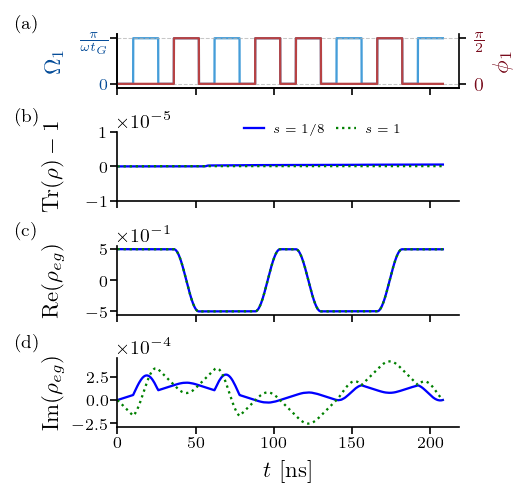

In [50]:
directory = "development/results/paper/sim_DD"
fileNames = ['DD_xy8_s8', 'DD_xy8_s1']

colors = ["b", "r", "g"]
labels = [r"$s=1/8$", r"$s=1/2$", r"$s=1$"]
ls = ["-", "--", ":"]

fig, axes = plt.subplots(
    4,
    1,
    figsize=(3.4, 3.2),
    sharex=True,
    gridspec_kw={"height_ratios": [0.8, 1.0, 1.0, 1.0]},
)

# (a) pulse sequence
kwargs = getKwargs(directory, fileNames[0])
fig, ax = plotPulseSeq(fig=fig, ax=axes[0], **kwargs)
axes[0].set_xlabel("")

for i, fileName in [[0, fileNames[0]], [2, fileNames[1]]]:
    kwargs = getKwargs(directory, fileName)
    t_list, rdo_list = getResult(directory, fileName)

    omegaQ = 2 * np.pi * np.array(kwargs["freqQ"])
    omegaQmax = max(omegaQ)
    t = t_list / omegaQmax

    trace_list = [np.trace(rho) - 1 for rho in rdo_list]
    rho_eg_real = [dm[0, 1].real for dm in rdo_list]
    rho_eg_imag = [dm[0, 1].imag for dm in rdo_list]

    axes[1].plot(t, trace_list, color=colors[i], label=labels[i], ls=ls[i], lw=1.1)
    axes[2].plot(t, rho_eg_real, color=colors[i], label=labels[i], ls=ls[i], lw=1.1)
    axes[3].plot(t, rho_eg_imag, color=colors[i], label=labels[i], ls=ls[i], lw=1.1)

axes[1].set_ylim(-1e-5, 1e-5)
axes[1].set_ylabel(r"$\mathrm{Tr}(\rho)-1$")
axes[2].set_ylabel(r"$\mathrm{Re}(\rho_{eg})$")
axes[3].set_ylabel(r"$\mathrm{Im}(\rho_{eg})$")
axes[2].ticklabel_format(axis="y", style="sci", scilimits=(0, 0))
axes[3].ticklabel_format(axis="y", style="sci", scilimits=(0, 0))
axes[-1].set_xlabel(r"$t$ [ns]")

for ax in axes:
    ax.set_xlim(0)
    ax.tick_params(axis="both", labelsize=8, pad=1)

# panel labels
panel_labels = ["(a)", "(b)", "(c)", "(d)"]
for ax, label in zip(axes, panel_labels):
    ax.text(
        -0.3,
        1.35,
        label,
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=9,
        fontweight="bold",
    )

# one shared legend
axes[1].legend(
    fontsize=6,
    ncols=3,
    frameon=False,
    loc="upper center",
    bbox_to_anchor=(0.6, 1.3),
    handlelength=1.6,
    columnspacing=0.9,
)

fig.align_ylabels(axes)
fig.subplots_adjust(hspace=0.25)

fig.savefig(os.path.join(directory, "DD_xy8_comparison.pdf"), bbox_inches="tight")
fig.savefig(os.path.join(directory, "DD_xy8_comparison.svg"), bbox_inches="tight")